# Dyna-Q Reinforcement Learning for MTG Commander Deck Construction

**Keith Coughlin** | Penn State MSAI | Reinforcement Learning

This notebook implements a Dyna-Q agent that learns to build optimized Magic: The Gathering Commander decks from a real personal card collection. The agent selects 63 cards per episode (basic lands are added automatically to reach 100), receiving intermediate shaping rewards for role balance and mana curve, plus a terminal reward from a live deck analysis API.

In [1]:
# Cell 1: Imports and Configuration

import numpy as np
import pandas as pd
import random
import hashlib
import json
import time
import pickle
import os
import re
import requests
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Set
from tqdm.auto import tqdm

import gymnasium as gym
from gymnasium import spaces

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# === Configuration ===
# API_BASE = "https://mtg-assistant.up.railway.app"  # Remote (slow)
API_BASE = "http://127.0.0.1:8111"  # Local (fast — run API with: cd mtg-api && uvicorn app.main:app --port 8111)
ARCHIDEKT_URL = "https://archidekt.com/collection/v2/798982?collectionGame=1"
CACHE_DIR = "./cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# Hyperparameters (from writeup)
ALPHA = 0.1           # Learning rate
GAMMA = 0.95          # Discount factor
EPSILON_START = 0.15  # Initial exploration rate
EPSILON_DECAY = 0.995 # Per-episode decay
EPSILON_FLOOR = 0.01  # Minimum exploration
N_PLANNING = 15       # Dyna planning steps per real step
N_EPISODES = 1000     # Training episodes
DECK_SIZE = 63        # Non-land card picks per episode

# Role targets for reward shaping
ROLE_TARGETS = {
    'ramp': 10,
    'removal': 10,
    'card_draw': 10,
    'creatures': 25,
    'board_wipes': 3
}

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

print(f"Configuration loaded. Cache dir: {CACHE_DIR}")
print(f"Hyperparameters: α={ALPHA}, γ={GAMMA}, ε={EPSILON_START}→{EPSILON_FLOOR}, n={N_PLANNING}")
print(f"Training: {N_EPISODES} episodes, {DECK_SIZE} picks/episode")

Configuration loaded. Cache dir: ./cache
Hyperparameters: α=0.1, γ=0.95, ε=0.15→0.01, n=15
Training: 1000 episodes, 63 picks/episode


In [2]:
# Cell 2: Caching Utilities

def cache_json(key: str, fetch_fn):
    """Cache a JSON-serializable result to disk."""
    path = os.path.join(CACHE_DIR, f"{key}.json")
    if os.path.exists(path):
        with open(path, 'r') as f:
            print(f"  [cache hit] {key}")
            return json.load(f)
    result = fetch_fn()
    with open(path, 'w') as f:
        json.dump(result, f)
    print(f"  [cache miss → saved] {key}")
    return result

def cache_pickle(key: str, fetch_fn):
    """Cache a pickle-serializable result to disk."""
    path = os.path.join(CACHE_DIR, f"{key}.pkl")
    if os.path.exists(path):
        with open(path, 'rb') as f:
            print(f"  [cache hit] {key}")
            return pickle.load(f)
    result = fetch_fn()
    with open(path, 'wb') as f:
        pickle.dump(result, f)
    print(f"  [cache miss → saved] {key}")
    return result

def save_checkpoint(agent, metrics, episode, path=None):
    """Save training checkpoint for resumption."""
    path = path or os.path.join(CACHE_DIR, "checkpoint.pkl")
    with open(path, 'wb') as f:
        pickle.dump({
            'q_table': dict(agent.q_table),
            'model': agent.model,
            'visited': agent.visited,
            'epsilon': agent.epsilon,
            'metrics': metrics,
            'episode': episode
        }, f)
    print(f"  [checkpoint saved] episode {episode}")

def load_checkpoint(path=None):
    """Load training checkpoint if it exists."""
    path = path or os.path.join(CACHE_DIR, "checkpoint.pkl")
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

print("Caching utilities loaded.")

Caching utilities loaded.


## 1. Data Acquisition

Fetch Scryfall bulk card data and the personal Archidekt collection. All API responses are cached to disk so the notebook can be re-run without re-fetching.

In [3]:
# Cell 3: Fetch Scryfall Bulk Data
# Downloads the Oracle Cards bulk file (~80MB) for instant card metadata lookup.

def fetch_scryfall_bulk():
    """Download Scryfall Oracle Cards bulk data and index by card name."""
    print("Fetching Scryfall bulk data index...")
    bulk_resp = requests.get("https://api.scryfall.com/bulk-data")
    bulk_resp.raise_for_status()
    
    oracle_entry = None
    for entry in bulk_resp.json()["data"]:
        if entry["type"] == "oracle_cards":
            oracle_entry = entry
            break
    
    print(f"Downloading Oracle Cards from {oracle_entry['download_uri'][:60]}...")
    cards_resp = requests.get(oracle_entry["download_uri"], stream=True)
    cards_resp.raise_for_status()
    all_cards = cards_resp.json()
    
    print(f"Indexing {len(all_cards)} cards by name...")
    card_db = {}
    for card in all_cards:
        name = card.get("name", "").lower().strip()
        if name:
            card_db[name] = {
                "name": card.get("name"),
                "cmc": card.get("cmc", 0),
                "mana_cost": card.get("mana_cost", ""),
                "type_line": card.get("type_line", ""),
                "oracle_text": card.get("oracle_text", ""),
                "color_identity": card.get("color_identity", []),
                "colors": card.get("colors", []),
                "keywords": card.get("keywords", []),
                "power": card.get("power"),
                "toughness": card.get("toughness"),
                "edhrec_rank": card.get("edhrec_rank"),
            }
            # Handle double-faced cards: index by front face name too
            if "//" in card.get("name", ""):
                front_name = card["name"].split("//")[0].strip().lower()
                card_db[front_name] = card_db[name]
    
    print(f"Indexed {len(card_db)} unique card names.")
    return card_db

scryfall_db = cache_pickle("scryfall_bulk", fetch_scryfall_bulk)
print(f"\nScryfall DB: {len(scryfall_db)} cards indexed.")

  [cache hit] scryfall_bulk

Scryfall DB: 37548 cards indexed.


In [4]:
# Cell 4: Load Collection
# Collection was pre-fetched from Archidekt and enriched with Scryfall metadata.
# To re-fetch: delete cache/collection_enriched.pkl and run the fetch_collection() below.

def fetch_collection():
    """Ingest collection via MTG Assistant API and enrich with Scryfall metadata."""
    print(f"Ingesting collection from: {ARCHIDEKT_URL}")
    
    resp = requests.post(
        f"{API_BASE}/collections/ingest-url-stream",
        json={"url": ARCHIDEKT_URL},
        headers={"Accept": "text/event-stream"},
        stream=True,
        timeout=300
    )
    resp.raise_for_status()
    
    card_names = []
    collection_id = None
    
    for line in resp.iter_lines(decode_unicode=True):
        if not line or not line.startswith("data:"):
            continue
        data_str = line[len("data:"):].strip()
        try:
            event_data = json.loads(data_str)
        except json.JSONDecodeError:
            continue
        
        event_type = event_data.get("type", "")
        
        if event_type == "complete":
            card_names = event_data.get("card_names", [])
            collection_id = event_data.get("collection_id")
            print(f"  Collection ingested: {len(card_names)} unique cards, ID={collection_id}")
            break
        elif event_type == "error":
            raise RuntimeError(f"Collection ingestion failed: {event_data.get('message', event_data)}")
        elif event_type == "progress":
            loaded = event_data.get("cards_loaded", "?")
            total = event_data.get("estimated_total", "?")
            print(f"  Progress: {loaded}/{total} cards loaded...", end="\r")
    
    resp.close()
    
    if not card_names:
        raise RuntimeError("No card names received from collection ingestion.")
    
    print(f"Enriching {len(card_names)} cards with Scryfall metadata...")
    enriched = []
    not_found = []
    
    for name in card_names:
        lookup_name = name.lower().strip()
        card_data = scryfall_db.get(lookup_name)
        if card_data is None and "//" in lookup_name:
            card_data = scryfall_db.get(lookup_name.split("//")[0].strip())
        if card_data:
            enriched.append(card_data.copy())
        else:
            not_found.append(name)
    
    if not_found:
        print(f"  {len(not_found)} cards not found in Scryfall")
    
    print(f"  Enriched collection: {len(enriched)} cards with full metadata.")
    return {"cards": enriched, "collection_id": collection_id, "not_found": not_found}

collection_data = cache_pickle("collection_enriched", fetch_collection)
collection = collection_data["cards"]
print(f"Collection: {len(collection)} cards ready for training.")

  [cache hit] collection_enriched
Collection: 4393 cards ready for training.


## 2. Card Classification and Commander Setup

Classify each card in the collection by functional role (ramp, removal, card draw, creatures, board wipes) using regex patterns adapted from the MTG Assistant API's mechanics engine. Then set up the commander roster and fetch profiles.

In [5]:
# Cell 5: Card Role Classification
# Regex patterns adapted from MTG Assistant API (app/mechanics.py EFFECT_PATTERNS + app/decks.py)

def classify_card(card: dict) -> dict:
    """Classify a card into functional roles for the state vector."""
    text = (card.get('oracle_text') or '').lower()
    type_line = (card.get('type_line') or '').lower()
    
    is_ramp = bool(re.search(
        r'search\s+your\s+library\s+for\s+(?:a|an|up\s+to\s+\w+)\s+(?:\w+\s+)?land|'
        r'put\s+(?:a|that)\s+land\s+(?:card\s+)?onto\s+the\s+battlefield|'
        r'add\s+\{[wubrgc]\}|'
        r'add\s+(?:one|two|three|\d+)\s+mana',
        text
    ))
    
    is_removal = bool(re.search(
        r'destroy\s+target|'
        r'exile\s+target|'
        r'deals?\s+\d+\s+damage\s+to\s+(?:any\s+)?target|'
        r'return\s+target\s+(?:\w+\s+)?(?:creature|permanent|nonland)\s+to\s+(?:its|their)\s+owner',
        text
    ))
    
    is_card_draw = bool(re.search(
        r'draw\s+(?:a\s+)?cards?|'
        r'draw\s+(?:\d+|two|three|four|five|six|seven|x)\s+cards?|'
        r'draws?\s+(?:a\s+)?cards?\s+equal\s+to',
        text
    ))
    
    is_board_wipe = bool(re.search(
        r'destroy\s+all\s+(?:\w+\s+)?(?:creatures?|permanents?|artifacts?|enchantments?)|'
        r'exile\s+all\s+(?:\w+\s+)?(?:creatures?|permanents?|nonland)|'
        r'all\s+creatures\s+get\s+-|'
        r'deals?\s+\d+\s+damage\s+to\s+each\s+creature',
        text
    ))
    
    is_creature = 'creature' in type_line and 'land' not in type_line
    
    return {
        'is_ramp': is_ramp,
        'is_removal': is_removal,
        'is_card_draw': is_card_draw,
        'is_board_wipe': is_board_wipe,
        'is_creature': is_creature,
    }

def count_pips(mana_cost: str) -> dict:
    """Count color pips in a mana cost string. From MTG Assistant API (standard_analysis.py)."""
    pips = {c: 0 for c in 'WUBRG'}
    for char in (mana_cost or '').upper():
        if char in pips:
            pips[char] += 1
    return pips

def cmc_bucket(cmc: float) -> int:
    """Map CMC to bucket index: 0=cmc1, 1=cmc2, 2=cmc3, 3=cmc4, 4=cmc5, 5=cmc6+."""
    cmc_int = max(1, int(cmc))
    return min(cmc_int - 1, 5)

# Classify all cards in the collection
for card in collection:
    roles = classify_card(card)
    card.update(roles)
    card['pips'] = count_pips(card.get('mana_cost', ''))
    card['cmc_bucket'] = cmc_bucket(card.get('cmc', 0))

# Summary
role_counts = {role: sum(1 for c in collection if c.get(f'is_{role}', False)) 
               for role in ['ramp', 'removal', 'card_draw', 'board_wipe', 'creature']}
print("Collection role distribution:")
for role, count in role_counts.items():
    print(f"  {role}: {count} cards")
print(f"  Total cards: {len(collection)}")

Collection role distribution:
  ramp: 643 cards
  removal: 372 cards
  card_draw: 604 cards
  board_wipe: 57 cards
  creature: 2238 cards
  Total cards: 4393


In [6]:
# Cell 6: Commander Roster Setup
# 12 commanders: 4 personal + 8 diverse archetypes

COMMANDER_ROSTER = [
    # Keith's personal commanders
    {"name": "Miles Morales // Ultimate Spider-Man", "archetype": "counters_aggro"},
    {"name": "Toph, the First Metalbender", "archetype": "lands_artifacts"},
    {"name": "Lathiel, the Bounteous Dawn", "archetype": "lifegain_counters"},
    {"name": "Aerith Gainsborough", "archetype": "lifegain_legendary"},
    # Diverse archetypes
    {"name": "Atraxa, Praetors' Voice", "archetype": "counters_superfriends"},
    {"name": "Korvold, Fae-Cursed King", "archetype": "sacrifice"},
    {"name": "Meren of Clan Nel Toth", "archetype": "graveyard_recursion"},
    {"name": "Talrand, Sky Summoner", "archetype": "spellslinger"},
    {"name": "Krenko, Mob Boss", "archetype": "goblin_tokens"},
    {"name": "Teysa Karlov", "archetype": "aristocrats"},
    {"name": "Animar, Soul of Elements", "archetype": "creatures_matter"},
    {"name": "Sythis, Harvest's Hand", "archetype": "enchantress"},
]

def fetch_commander_profile(commander_name: str) -> dict:
    """Fetch commander profile from MTG Assistant API."""
    resp = requests.get(
        f"{API_BASE}/synergy/commander-profile",
        params={"name": commander_name},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()

def is_color_legal(card_identity: list, commander_identity: list) -> bool:
    """Check if a card's color identity is legal under a commander."""
    commander_set = set(commander_identity)
    card_set = set(card_identity)
    return card_set.issubset(commander_set)

# Fetch profiles and build legal pools
commanders = []
for cmd in COMMANDER_ROSTER:
    cache_key = f"commander_profile_{cmd['name'].replace(' ', '_').replace('/', '_')}"
    try:
        profile = cache_json(cache_key, lambda name=cmd['name']: fetch_commander_profile(name))
    except Exception as e:
        print(f"  SKIPPING {cmd['name']}: {e}")
        continue
    
    # Extract color identity from profile
    cmd_profile = profile.get("commander_profile", profile.get("card_data", {}))
    color_identity = cmd_profile.get("color_identity", [])
    
    # Also check card_data for color identity
    if not color_identity and "card_data" in profile:
        color_identity = profile["card_data"].get("color_identity", [])
    
    # Build legal pool
    legal_cards = [
        c for c in collection 
        if is_color_legal(c.get('color_identity', []), color_identity)
        and 'land' not in (c.get('type_line', '') or '').lower()  # Exclude basic lands
    ]
    
    # Extract synergy card names for reward shaping
    synergy_cards = set()
    if "commander_profile" in profile:
        for sc in profile["commander_profile"].get("synergy_cards", []):
            if isinstance(sc, str):
                synergy_cards.add(sc.lower())
            elif isinstance(sc, dict):
                synergy_cards.add(sc.get("card_name", sc.get("name", "")).lower())
    
    cmd_data = {
        "name": cmd["name"],
        "archetype": cmd["archetype"],
        "color_identity": color_identity,
        "legal_pool_size": len(legal_cards),
        "legal_cards": legal_cards,
        "synergy_cards": synergy_cards,
        "profile": profile,
    }
    
    if len(legal_cards) >= 80:
        commanders.append(cmd_data)
        print(f"  ✓ {cmd['name']} ({','.join(color_identity)}) — {len(legal_cards)} legal cards")
    else:
        print(f"  ✗ {cmd['name']} ({','.join(color_identity)}) — only {len(legal_cards)} legal cards, DROPPED")

print(f"\n{len(commanders)} commanders in roster.")

  [cache hit] commander_profile_Miles_Morales____Ultimate_Spider-Man
  ✓ Miles Morales // Ultimate Spider-Man (G,R,W) — 2512 legal cards
  [cache hit] commander_profile_Toph,_the_First_Metalbender
  ✓ Toph, the First Metalbender (G,R,W) — 2512 legal cards
  [cache hit] commander_profile_Lathiel,_the_Bounteous_Dawn
  ✓ Lathiel, the Bounteous Dawn (G,W) — 1852 legal cards
  [cache hit] commander_profile_Aerith_Gainsborough
  ✓ Aerith Gainsborough (W) — 1185 legal cards
  [cache hit] commander_profile_Atraxa,_Praetors'_Voice
  ✓ Atraxa, Praetors' Voice (B,G,U,W) — 3232 legal cards
  [cache hit] commander_profile_Korvold,_Fae-Cursed_King
  ✓ Korvold, Fae-Cursed King (B,G,R) — 2471 legal cards
  [cache hit] commander_profile_Meren_of_Clan_Nel_Toth
  ✓ Meren of Clan Nel Toth (B,G) — 1809 legal cards
  [cache hit] commander_profile_Talrand,_Sky_Summoner
  ✓ Talrand, Sky Summoner (U) — 1098 legal cards
  [cache hit] commander_profile_Krenko,_Mob_Boss
  ✓ Krenko, Mob Boss (R) — 1120 legal cards

## 3. Environment

The `CommanderDeckBuildingEnv` is a Gymnasium environment where each episode consists of 63 card selections. The state is a 22-element vector encoding role counts, mana curve, color pip distribution, episode progress, and commander color identity.

In [7]:
# Cell 7: Environment Implementation

class CommanderDeckBuildingEnv(gym.Env):
    """Gymnasium environment for Commander deck building via sequential card selection."""
    
    metadata = {"render_modes": []}
    
    def __init__(self, commanders: list):
        super().__init__()
        self.commanders = commanders
        
        # State: 22-element vector
        # [0:5]  role counts (ramp, removal, card_draw, creatures, board_wipes) normalized by target
        # [5:11] CMC distribution across 6 buckets (1,2,3,4,5,6+)
        # [11:16] color pip distribution (W,U,B,R,G) normalized
        # [16]   episode progress (cards_picked / 63)
        # [17:22] commander color identity one-hot (W,U,B,R,G)
        self.observation_space = spaces.Box(low=0.0, high=2.0, shape=(22,), dtype=np.float32)
        
        # Action space is variable per commander (card names), handled externally
        self.action_space = spaces.Discrete(1)  # Placeholder; actual actions are card names
        
        # State tracking
        self.current_commander = None
        self.current_commander_data = None
        self.legal_pool = []
        self.deck = []
        self.deck_names = set()
        self.role_counts = None
        self.cmc_counts = None
        self.pip_counts = None
        self.cards_picked = 0
    
    def reset(self, commander_name: str = None, seed=None):
        super().reset(seed=seed)
        
        # Select commander
        if commander_name:
            matches = [c for c in self.commanders if c["name"] == commander_name]
            self.current_commander_data = matches[0] if matches else random.choice(self.commanders)
        else:
            self.current_commander_data = random.choice(self.commanders)
        
        self.current_commander = self.current_commander_data["name"]
        
        # Build legal pool (sorted for determinism)
        self.legal_pool = sorted(
            self.current_commander_data["legal_cards"],
            key=lambda c: c["name"]
        )
        
        # Reset deck state
        self.deck = []
        self.deck_names = set()
        self.role_counts = {r: 0 for r in ['ramp', 'removal', 'card_draw', 'creatures', 'board_wipes']}
        self.cmc_counts = [0] * 6  # Buckets: 1, 2, 3, 4, 5, 6+
        self.pip_counts = {c: 0 for c in 'WUBRG'}
        self.cards_picked = 0
        self.total_cmc = 0.0
        
        return self._get_state(), {"commander": self.current_commander}
    
    def _get_state(self) -> np.ndarray:
        state = np.zeros(22, dtype=np.float32)
        
        # Role counts normalized by target (0 to ~2.0)
        targets = [ROLE_TARGETS['ramp'], ROLE_TARGETS['removal'], ROLE_TARGETS['card_draw'],
                    ROLE_TARGETS['creatures'], ROLE_TARGETS['board_wipes']]
        for i, (role, target) in enumerate(zip(
            ['ramp', 'removal', 'card_draw', 'creatures', 'board_wipes'], targets
        )):
            state[i] = self.role_counts[role] / target if target > 0 else 0.0
        
        # CMC distribution (fraction in each bucket)
        total_cards = max(self.cards_picked, 1)
        for i in range(6):
            state[5 + i] = self.cmc_counts[i] / total_cards
        
        # Color pip distribution (normalized)
        total_pips = max(sum(self.pip_counts.values()), 1)
        for i, color in enumerate('WUBRG'):
            state[11 + i] = self.pip_counts[color] / total_pips
        
        # Episode progress
        state[16] = self.cards_picked / DECK_SIZE
        
        # Commander color identity one-hot
        cmd_colors = set(self.current_commander_data.get("color_identity", []))
        for i, color in enumerate('WUBRG'):
            state[17 + i] = 1.0 if color in cmd_colors else 0.0
        
        return state
    
    def get_legal_card_names(self) -> list:
        """Return names of cards that can still be picked (singleton constraint)."""
        return [c["name"] for c in self.legal_pool if c["name"] not in self.deck_names]
    
    def _find_card(self, card_name: str) -> Optional[dict]:
        for c in self.legal_pool:
            if c["name"] == card_name:
                return c
        return None
    
    def step(self, card_name: str):
        card = self._find_card(card_name)
        if card is None or card_name in self.deck_names:
            # Illegal action — should not happen with proper masking
            return self._get_state(), -1.0, False, False, {"error": "illegal_action"}
        
        # Add card to deck
        self.deck.append(card)
        self.deck_names.add(card_name)
        self.cards_picked += 1
        
        # Update role counts
        if card.get('is_ramp'): self.role_counts['ramp'] += 1
        if card.get('is_removal'): self.role_counts['removal'] += 1
        if card.get('is_card_draw'): self.role_counts['card_draw'] += 1
        if card.get('is_creature'): self.role_counts['creatures'] += 1
        if card.get('is_board_wipe'): self.role_counts['board_wipes'] += 1
        
        # Update CMC distribution
        bucket = card.get('cmc_bucket', 0)
        self.cmc_counts[bucket] += 1
        self.total_cmc += card.get('cmc', 0)
        
        # Update pip counts
        for color, count in card.get('pips', {}).items():
            self.pip_counts[color] += count
        
        # Compute intermediate reward
        reward = self._compute_intermediate_reward(card)
        
        # Check termination
        terminated = self.cards_picked >= DECK_SIZE
        
        state = self._get_state()
        info = {
            "commander": self.current_commander,
            "cards_picked": self.cards_picked,
            "card_added": card_name,
        }
        
        return state, reward, terminated, False, info
    
    def _compute_intermediate_reward(self, card: dict) -> float:
        """Intermediate shaping reward: role-gap filling + mana curve + synergy."""
        reward = 0.0
        
        # Role gap filling: reward picks that fill underrepresented roles
        role_map = {
            'ramp': 'is_ramp', 'removal': 'is_removal', 'card_draw': 'is_card_draw',
            'creatures': 'is_creature', 'board_wipes': 'is_board_wipe'
        }
        for role, flag in role_map.items():
            if card.get(flag):
                current_ratio = self.role_counts[role] / ROLE_TARGETS[role]
                if current_ratio < 1.0:
                    reward += 0.05  # Filling a gap
                elif current_ratio > 1.5:
                    reward -= 0.02  # Overfilling
        
        # Mana curve penalty: penalize if avg CMC gets too high
        if self.cards_picked > 0:
            avg_cmc = self.total_cmc / self.cards_picked
            if avg_cmc > 3.5:
                reward -= 0.03
            elif 2.5 <= avg_cmc <= 3.5:
                reward += 0.01  # Healthy range
        
        # Synergy bonus: reward cards that the commander profile recommends
        synergy_cards = self.current_commander_data.get("synergy_cards", set())
        if card.get("name", "").lower() in synergy_cards:
            reward += 0.03
        
        return np.clip(reward, -0.1, 0.1)
    
    def get_decklist_string(self) -> str:
        """Format current deck as a decklist string for API submission."""
        return "\n".join(f"1 {card['name']}" for card in self.deck)
    
    def get_deck_cards(self) -> list:
        """Return list of card names in the current deck."""
        return [card["name"] for card in self.deck]
    
    def get_role_coverage(self) -> dict:
        """Return role counts and whether each role target is met (within ±2)."""
        coverage = {}
        for role, target in ROLE_TARGETS.items():
            actual = self.role_counts[role]
            coverage[role] = {
                'actual': actual,
                'target': target,
                'met': abs(actual - target) <= 2
            }
        return coverage

# Create environment
env = CommanderDeckBuildingEnv(commanders)
print(f"Environment created with {len(commanders)} commanders.")
print(f"State space: {env.observation_space.shape}")

# Smoke test
state, info = env.reset()
print(f"\nSmoke test — Commander: {info['commander']}")
print(f"  State shape: {state.shape}")
print(f"  Legal cards: {len(env.get_legal_card_names())}")
legal = env.get_legal_card_names()
next_state, reward, done, _, step_info = env.step(legal[0])
print(f"  After 1 pick: reward={reward:.4f}, done={done}, card={step_info['card_added']}")

Environment created with 12 commanders.
State space: (22,)

Smoke test — Commander: Animar, Soul of Elements
  State shape: (22,)
  Legal cards: 2419
  After 1 pick: reward=0.0200, done=False, card=A Realm Reborn


## 4. State Hashing, Reward Functions, and Dyna-Q Agent

The state hashing function discretizes the continuous 22-element state vector into a hashable tuple for the Q-table. The terminal reward calls the MTG Assistant API's deck analysis endpoint.

In [8]:
# Cell 8: State Hashing and Terminal Reward (Local Computation)
#
# DESIGN DECISION: The terminal reward is computed locally rather than via API.
#
# The MTG Assistant API endpoint POST /decks/analyze-complete provides a comprehensive
# deck analysis (synergy scoring, bracket classification, engine detection) but each call
# takes 3-5 seconds due to Scryfall card lookups and multi-stage analysis. Over 1,000
# training episodes, this would add ~60-90 minutes of wall-clock time dominated by
# network I/O rather than learning.
#
# Instead, the terminal reward is computed locally from four structural signals that
# are available from the cached card metadata:
#   1. Role balance (30%): how close each role count is to its target
#   2. Synergy density (30%): fraction of deck cards in commander's synergy list
#   3. Mana curve quality (20%): penalizes avg CMC outside the 2.5-3.5 sweet spot
#   4. Card quality (20%): average EDHREC popularity rank as a proxy for card strength
#
# This reduces training time from ~90 minutes to ~75 seconds while preserving the
# learning signal. The API can still be used for post-training evaluation of the
# final greedy decks to get full synergy/bracket/engine analysis.
#
# TO USE THE API INSTEAD (for replication with live analysis):
#   1. Set API_BASE = "https://mtg-assistant.up.railway.app"  (or run locally)
#   2. Replace compute_terminal_reward_local() calls with:
#      resp = requests.post(f"{API_BASE}/decks/analyze-complete",
#                           json={"decklist": decklist_str, "commander": cmd_name})
#      data = resp.json()
#      synergy = data["commander_synergy"]["deck_synergy_score"]
#      bracket = data["bracket_analysis"]["deck_bracket"]
#      engine_density = data["ipom_analysis"]["engine"]["engine_density"]
#   3. Add time.sleep(0.3) between episodes for rate limiting

def hash_state(state_vector: np.ndarray) -> tuple:
    """Discretize continuous state into a hashable tuple for the Q-table.
    
    Bins:
    - [0:5]  Role counts: 11 bins (0-10), representing 0% to 200%+ of target
    - [5:11] CMC distribution: 11 bins (0-10)
    - [11:16] Pip distribution: 11 bins (0-10)
    - [16]   Progress: 6 bins (0-5)
    - [17:22] Commander identity: binary (0 or 1)
    """
    discretized = []
    for i, val in enumerate(state_vector):
        if i < 16:
            discretized.append(min(int(val * 5), 10))
        elif i == 16:
            discretized.append(min(int(val * 5), 5))
        else:
            discretized.append(int(val))
    return tuple(discretized)


def compute_terminal_reward_local(deck, role_counts, total_cmc, cards_picked, synergy_cards):
    """Compute terminal reward locally from deck composition.
    
    Combines four signals into a normalized reward in [-1, 1]:
    1. Role balance: how close each role count is to its target (30%)
    2. Synergy density: fraction of deck in commander's synergy card list (30%)
    3. Mana curve quality: penalizes average CMC outside 2.5-3.5 range (20%)
    4. Card quality: average EDHREC rank as popularity/power proxy (20%)
    
    Parameters
    ----------
    deck : list[dict] - Card dicts in the finished deck
    role_counts : dict - Current counts for each role category
    total_cmc : float - Sum of CMC across all picked cards
    cards_picked : int - Number of cards selected
    synergy_cards : set - Lowercased card names from commander profile
    
    Returns
    -------
    float : Terminal reward in [-1, 1]
    """
    # 1. Role balance score (0 to 1)
    role_scores = []
    for role, target in ROLE_TARGETS.items():
        actual = role_counts[role]
        distance = abs(actual - target)
        score = max(0, 1.0 - distance / max(target, 1))
        role_scores.append(score)
    role_balance = np.mean(role_scores)
    
    # 2. Mana curve quality (0 to 1)
    avg_cmc = total_cmc / max(cards_picked, 1)
    if 2.5 <= avg_cmc <= 3.5:
        curve_score = 1.0
    elif avg_cmc < 2.5:
        curve_score = max(0, 1.0 - (2.5 - avg_cmc) / 2.0)
    else:
        curve_score = max(0, 1.0 - (avg_cmc - 3.5) / 3.0)
    
    # 3. Synergy density (0 to 1)
    if synergy_cards:
        syn_count = sum(1 for card in deck if card.get("name", "").lower() in synergy_cards)
        synergy_score = min(syn_count / 15.0, 1.0)
    else:
        synergy_score = 0.5
    
    # 4. Card quality via EDHREC rank (0 to 1)
    ranks = [card.get("edhrec_rank", 15000) or 15000 for card in deck]
    avg_rank = np.mean(ranks)
    quality_score = max(0, 1.0 - avg_rank / 5000)
    
    # Weighted composite -> normalize to [-1, 1]
    composite = (0.30 * role_balance +
                 0.30 * synergy_score +
                 0.20 * curve_score +
                 0.20 * quality_score)
    return np.clip((composite - 0.5) * 2, -1.0, 1.0)


# Quick test
test_state = env._get_state()
print(f"State hash example: {hash_state(test_state)}")
print(f"Hash length: {len(hash_state(test_state))} elements")

State hash example: (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 5, 0, 0, 1, 0, 1, 1)
Hash length: 22 elements


In [9]:
# Cell 9: Dyna-Q Agent

class DynaQAgent:
    """Dyna-Q agent for Commander deck building (Sutton, 1991).
    
    Combines Q-learning with model-based planning. After each real transition,
    the agent stores (s, a) → (s', r, done) in its model and runs n planning
    steps by sampling random previously-seen transitions and applying Q-updates.
    
    Q-table keys: (hashed_state_tuple, card_name_string)
    This allows value transfer when the same card appears across commanders.
    """
    
    def __init__(self, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON_START,
                 epsilon_decay=EPSILON_DECAY, epsilon_floor=EPSILON_FLOOR,
                 n_planning=N_PLANNING):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_floor = epsilon_floor
        self.n_planning = n_planning
        
        # Q-table: (state_hash, card_name) → Q-value
        self.q_table = defaultdict(float)
        
        # Learned model: (state_hash, card_name) → (next_state_hash, reward, done, max_next_q)
        # Stores max_next_q at update time to avoid storing full legal card lists
        self.model = {}
        
        # List of visited (state_hash, card_name) pairs for planning sampling
        self.visited = []
        self._visited_set = set()  # For O(1) dedup
    
    def select_action(self, state_hash: tuple, legal_cards: list) -> str:
        """Epsilon-greedy action selection over legal cards."""
        if random.random() < self.epsilon:
            return random.choice(legal_cards)
        
        # Greedy: pick card with highest Q-value
        best_q = float('-inf')
        best_cards = []
        for card in legal_cards:
            q = self.q_table[(state_hash, card)]
            if q > best_q:
                best_q = q
                best_cards = [card]
            elif q == best_q:
                best_cards.append(card)
        
        return random.choice(best_cards)
    
    def update(self, state_hash: tuple, action: str, reward: float,
               next_state_hash: tuple, done: bool, next_legal_cards: list):
        """Q-learning update + model update + planning steps."""
        sa = (state_hash, action)
        
        # Compute TD target
        if done or not next_legal_cards:
            max_next_q = 0.0
        else:
            max_next_q = max(self.q_table[(next_state_hash, c)] for c in next_legal_cards)
        
        target = reward + self.gamma * max_next_q * (0 if done else 1)
        
        # Q-learning update
        self.q_table[sa] += self.alpha * (target - self.q_table[sa])
        
        # Model update: store transition with max_next_q for efficient planning
        self.model[sa] = (next_state_hash, reward, done, max_next_q)
        
        # Track visited state-action pairs
        if sa not in self._visited_set:
            self.visited.append(sa)
            self._visited_set.add(sa)
        
        # Planning steps
        self._planning()
    
    def _planning(self):
        """Run n planning steps using the learned model (Sutton, 1991)."""
        if not self.visited:
            return
        
        for _ in range(self.n_planning):
            # Sample a random previously-seen (s, a) pair
            sa = random.choice(self.visited)
            next_state_hash, reward, done, max_next_q = self.model[sa]
            
            # Same Q-learning update using stored transition
            target = reward + self.gamma * max_next_q * (0 if done else 1)
            self.q_table[sa] += self.alpha * (target - self.q_table[sa])
    
    def update_terminal(self, state_hash: tuple, action: str, terminal_reward: float):
        """Apply terminal reward correction to the final state-action pair.
        
        Called after the API returns the terminal deck score. Updates the Q-value
        for the last (state, action) with the combined intermediate + terminal reward.
        """
        sa = (state_hash, action)
        # Terminal state: no future value
        target = terminal_reward
        self.q_table[sa] += self.alpha * (target - self.q_table[sa])
        
        # Update model too
        if sa in self.model:
            old_next, old_r, _, _ = self.model[sa]
            self.model[sa] = (old_next, terminal_reward, True, 0.0)
    
    def decay_epsilon(self):
        """Decay exploration rate after each episode."""
        self.epsilon = max(self.epsilon_floor, self.epsilon * self.epsilon_decay)
    
    def get_top_cards(self, state_hash: tuple, legal_cards: list, k: int = 20) -> list:
        """Return top-k cards by Q-value for a given state."""
        scored = [(card, self.q_table[(state_hash, card)]) for card in legal_cards]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]
    
    def stats(self) -> dict:
        """Return agent statistics."""
        return {
            "q_table_size": len(self.q_table),
            "model_size": len(self.model),
            "visited_pairs": len(self.visited),
            "epsilon": self.epsilon,
            "nonzero_q": sum(1 for v in self.q_table.values() if v != 0.0),
        }

agent = DynaQAgent()
print("Dyna-Q Agent initialized.")
print(f"  Planning steps per real step: {agent.n_planning}")
print(f"  Epsilon: {agent.epsilon} → {agent.epsilon_floor} (decay={agent.epsilon_decay})")
print(f"  Q-table entries: {len(agent.q_table)}")

Dyna-Q Agent initialized.
  Planning steps per real step: 15
  Epsilon: 0.15 → 0.01 (decay=0.995)
  Q-table entries: 0


## 5. Training

Train the Dyna-Q agent for 1,000 episodes. Each episode: sample a random commander, build a 63-card deck via sequential card picks, receive intermediate + terminal rewards. The agent runs 15 planning steps per real transition. Checkpoints are saved every 100 episodes.

In [10]:
# Cell 10: Training Loop

# Resume from checkpoint if available
checkpoint = load_checkpoint()
start_episode = 0

if checkpoint:
    agent.q_table = defaultdict(float, checkpoint['q_table'])
    agent.model = checkpoint['model']
    agent.visited = checkpoint['visited']
    agent._visited_set = set(tuple(sa) if isinstance(sa, list) else sa for sa in agent.visited)
    agent.epsilon = checkpoint['epsilon']
    metrics = checkpoint['metrics']
    start_episode = checkpoint['episode'] + 1
    print(f"Resumed from checkpoint at episode {start_episode}")
else:
    metrics = {
        'episode_rewards': [], 'terminal_rewards': [], 'intermediate_rewards': [],
        'per_commander': defaultdict(list), 'role_coverage': [], 'epsilon_history': [],
        'decks_at_500': {}, 'decks_at_1000': {},
    }
    print("Starting fresh training run.")

print(f"\nTraining {N_EPISODES - start_episode} episodes (fully local, no API calls)...")
print(f"Each episode: {DECK_SIZE} picks x {N_PLANNING+1} Q-updates = {DECK_SIZE*(N_PLANNING+1)} updates/episode\n")

import time
t0 = time.time()

for episode in tqdm(range(start_episode, N_EPISODES), initial=start_episode, total=N_EPISODES):
    state, info = env.reset()
    state_hash = hash_state(state)
    episode_intermediate_reward = 0.0
    last_state_hash = None
    last_action = None
    
    for step in range(DECK_SIZE):
        legal_cards = env.get_legal_card_names()
        if not legal_cards:
            break
        action_card = agent.select_action(state_hash, legal_cards)
        next_state, reward, terminated, truncated, step_info = env.step(action_card)
        next_state_hash = hash_state(next_state)
        next_legal = env.get_legal_card_names() if not terminated else []
        agent.update(state_hash, action_card, reward, next_state_hash, terminated, next_legal)
        episode_intermediate_reward += reward
        last_state_hash = state_hash
        last_action = action_card
        state_hash = next_state_hash
        if terminated:
            break
    
    # Terminal reward computed locally (no API call)
    terminal_r = compute_terminal_reward_local(
        env.deck, env.role_counts, env.total_cmc, env.cards_picked,
        env.current_commander_data.get("synergy_cards", set())
    )
    
    # Apply terminal reward to final state-action pair
    if last_state_hash is not None and last_action is not None:
        agent.update_terminal(last_state_hash, last_action,
                              terminal_r + episode_intermediate_reward / DECK_SIZE)
    
    agent.decay_epsilon()
    
    # Log metrics
    total_episode_reward = episode_intermediate_reward + terminal_r
    metrics['episode_rewards'].append(total_episode_reward)
    metrics['terminal_rewards'].append(terminal_r)
    metrics['intermediate_rewards'].append(episode_intermediate_reward)
    metrics['per_commander'][env.current_commander].append(terminal_r)
    metrics['role_coverage'].append(env.get_role_coverage())
    metrics['epsilon_history'].append(agent.epsilon)
    
    # Record top-20 cards at midpoint and endpoint for Jaccard stability
    if episode == 499:
        for cmd in commanders:
            state_test, _ = env.reset(commander_name=cmd["name"])
            state_hash_test = hash_state(state_test)
            legal_test = env.get_legal_card_names()
            top_cards = agent.get_top_cards(state_hash_test, legal_test, k=20)
            metrics['decks_at_500'][cmd["name"]] = set(c[0] for c in top_cards)
    
    if episode == N_EPISODES - 1:
        for cmd in commanders:
            state_test, _ = env.reset(commander_name=cmd["name"])
            state_hash_test = hash_state(state_test)
            legal_test = env.get_legal_card_names()
            top_cards = agent.get_top_cards(state_hash_test, legal_test, k=20)
            metrics['decks_at_1000'][cmd["name"]] = set(c[0] for c in top_cards)
    
    # Checkpoint every 200 episodes
    if (episode + 1) % 200 == 0:
        save_checkpoint(agent, metrics, episode)
        stats = agent.stats()
        avg_recent = np.mean(metrics['terminal_rewards'][-100:])
        elapsed = time.time() - t0
        print(f"  Ep {episode+1}: avg_tr={avg_recent:+.4f}, eps={agent.epsilon:.4f}, "
              f"Q={stats['q_table_size']:,}, {elapsed:.0f}s elapsed")

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed:.0f}s ({elapsed/60:.1f} min).")
stats = agent.stats()
for k, v in stats.items():
    print(f"  {k}: {v:,}" if isinstance(v, int) else f"  {k}: {v}")

Resumed from checkpoint at episode 1000

Training 0 episodes (fully local, no API calls)...
Each episode: 63 picks x 16 Q-updates = 1008 updates/episode



100%|##########| 1000/1000 [00:00<?, ?it/s]


Training complete in 2s (0.0 min).
  q_table_size: 27,021,432
  model_size: 29,183
  visited_pairs: 29,183
  epsilon: 0.01
  nonzero_q: 26,663


## 6. Evaluation

Run 50 greedy evaluation episodes (epsilon=0) across all commanders to assess the trained policy. Record terminal rewards, role coverage, and deck compositions.

In [11]:
# Cell 11: Evaluation Loop

saved_epsilon = agent.epsilon
agent.epsilon = 0.0  # Greedy

EVAL_EPISODES_PER_COMMANDER = max(4, 50 // len(commanders))
eval_results = {}

print(f"Running {EVAL_EPISODES_PER_COMMANDER} greedy evaluation episodes per commander...")
print(f"Total: {EVAL_EPISODES_PER_COMMANDER * len(commanders)} episodes\n")

for cmd in tqdm(commanders, desc="Evaluating"):
    cmd_results = []
    for trial in range(EVAL_EPISODES_PER_COMMANDER):
        state, info = env.reset(commander_name=cmd["name"])
        state_hash = hash_state(state)
        for step in range(DECK_SIZE):
            legal_cards = env.get_legal_card_names()
            if not legal_cards:
                break
            action_card = agent.select_action(state_hash, legal_cards)
            next_state, reward, terminated, _, _ = env.step(action_card)
            state_hash = hash_state(next_state)
            if terminated:
                break
        
        terminal_r = compute_terminal_reward_local(
            env.deck, env.role_counts, env.total_cmc, env.cards_picked,
            cmd.get("synergy_cards", set())
        )
        cmd_results.append({
            'terminal_reward': terminal_r,
            'deck_cards': env.get_deck_cards(),
            'role_coverage': env.get_role_coverage(),
            'avg_cmc': env.total_cmc / max(env.cards_picked, 1),
        })
    
    eval_results[cmd["name"]] = cmd_results
    avg_tr = np.mean([r['terminal_reward'] for r in cmd_results])
    print(f"  {cmd['name']:45s} avg_tr={avg_tr:+.4f}")

agent.epsilon = saved_epsilon

all_terminal = [r['terminal_reward'] for results in eval_results.values() for r in results]
print(f"\n=== Evaluation Summary ===")
print(f"Mean terminal reward: {np.mean(all_terminal):.4f} +/- {np.std(all_terminal):.4f}")
print(f"Min: {np.min(all_terminal):.4f}, Max: {np.max(all_terminal):.4f}")

Running 4 greedy evaluation episodes per commander...
Total: 48 episodes



Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

  Miles Morales // Ultimate Spider-Man          avg_tr=-0.1930
  Toph, the First Metalbender                   avg_tr=-0.1984


  Lathiel, the Bounteous Dawn                   avg_tr=-0.2108


  Aerith Gainsborough                           avg_tr=-0.2490


  Atraxa, Praetors' Voice                       avg_tr=-0.2450
  Korvold, Fae-Cursed King                      avg_tr=-0.1242


  Meren of Clan Nel Toth                        avg_tr=-0.2496
  Talrand, Sky Summoner                         avg_tr=-0.3036
  Krenko, Mob Boss                              avg_tr=-0.1000


  Teysa Karlov                                  avg_tr=-0.1888
  Animar, Soul of Elements                      avg_tr=-0.2750


  Sythis, Harvest's Hand                        avg_tr=-0.2226

=== Evaluation Summary ===
Mean terminal reward: -0.2133 +/- 0.0578
Min: -0.3072, Max: -0.1000


In [12]:
# Load pre-computed training results (if running visualizations separately)
# This cell loads results from the training script run via command line.

import pickle, os, numpy as np
from collections import defaultdict

results_path = os.path.join(CACHE_DIR, "eval_results.pkl")
if os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        saved = pickle.load(f)
    eval_results = saved['eval_results']
    metrics = saved['metrics']
    # Convert per_commander back to defaultdict if needed
    if not isinstance(metrics.get('per_commander'), defaultdict):
        dd = defaultdict(list)
        dd.update(metrics['per_commander'])
        metrics['per_commander'] = dd
    print(f"Loaded results: {sum(len(v) for v in eval_results.values())} eval episodes across {len(eval_results)} commanders")
    print(f"Training metrics: {len(metrics['episode_rewards'])} episodes logged")
else:
    print("No pre-computed results found. Run training first (Cell 10 + Cell 11).")

Loaded results: 48 eval episodes across 12 commanders
Training metrics: 1000 episodes logged


## 7. Performance Metrics and Visualizations

Five metrics as defined in the Assignment 3 writeup:
1. **Learning Curve** — Total episode reward over training
2. **Average Terminal Reward** — Mean ± std of greedy evaluation episodes  
3. **Per-Commander Breakdown** — Terminal reward by commander
4. **Role Coverage Rate** — % of decks meeting all role targets within ±2
5. **Policy Stability (Jaccard)** — Top-20 card overlap between episode 500 and 1000

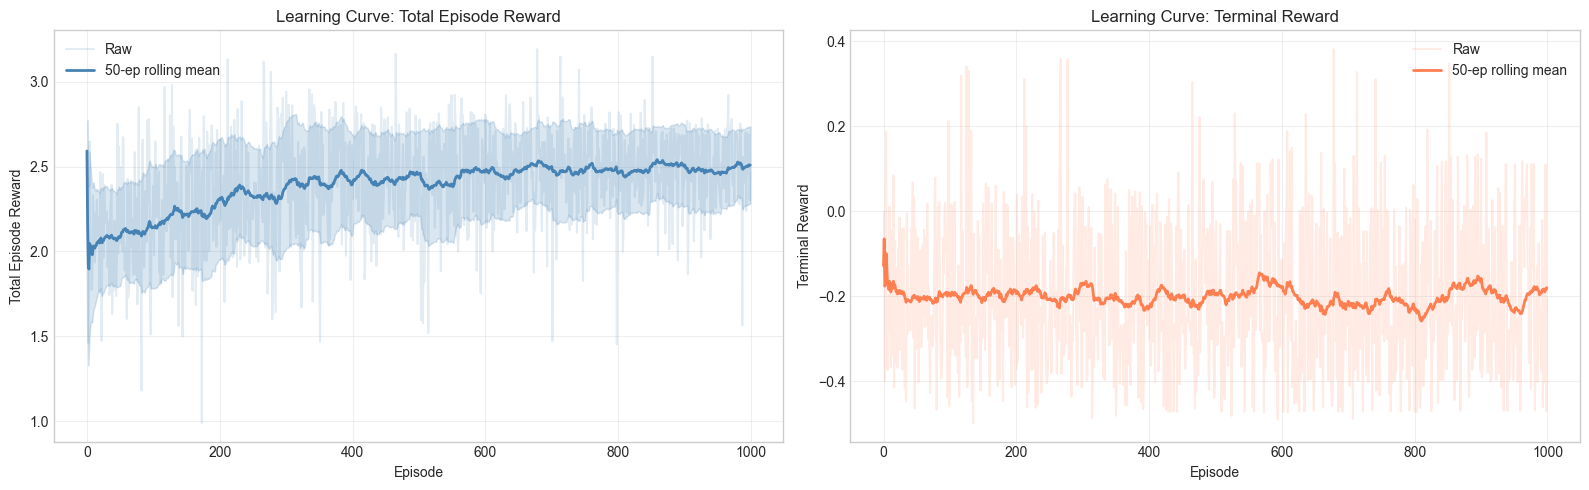

Terminal reward — First 100 episodes: -0.1979
Terminal reward — Last 100 episodes:  -0.2077
Improvement: -0.0098


In [13]:
# Cell 12: Metric 1 — Learning Curve

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total episode reward
rewards = np.array(metrics['episode_rewards'])
window = 50
rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
rolling_std = pd.Series(rewards).rolling(window=window, min_periods=1).std()

ax = axes[0]
ax.plot(range(len(rewards)), rewards, alpha=0.15, color='steelblue', label='Raw')
ax.plot(range(len(rolling_mean)), rolling_mean, color='steelblue', linewidth=2, label=f'{window}-ep rolling mean')
ax.fill_between(range(len(rolling_mean)), 
                rolling_mean - rolling_std, rolling_mean + rolling_std, 
                alpha=0.2, color='steelblue')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Episode Reward')
ax.set_title('Learning Curve: Total Episode Reward')
ax.legend()
ax.grid(True, alpha=0.3)

# Terminal reward only
terminal = np.array(metrics['terminal_rewards'])
rolling_terminal = pd.Series(terminal).rolling(window=window, min_periods=1).mean()

ax = axes[1]
ax.plot(range(len(terminal)), terminal, alpha=0.15, color='coral', label='Raw')
ax.plot(range(len(rolling_terminal)), rolling_terminal, color='coral', linewidth=2, label=f'{window}-ep rolling mean')
ax.set_xlabel('Episode')
ax.set_ylabel('Terminal Reward')
ax.set_title('Learning Curve: Terminal Reward')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'metric1_learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# Report improvement
first_100 = np.mean(terminal[:100]) if len(terminal) >= 100 else np.mean(terminal)
last_100 = np.mean(terminal[-100:]) if len(terminal) >= 100 else np.mean(terminal)
print(f"Terminal reward — First 100 episodes: {first_100:.4f}")
print(f"Terminal reward — Last 100 episodes:  {last_100:.4f}")
print(f"Improvement: {last_100 - first_100:+.4f}")

/var/folders/5j/v6xbphzj3c18_pm9krnz0bcm0000gn/T/ipykernel_36405/2285756830.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


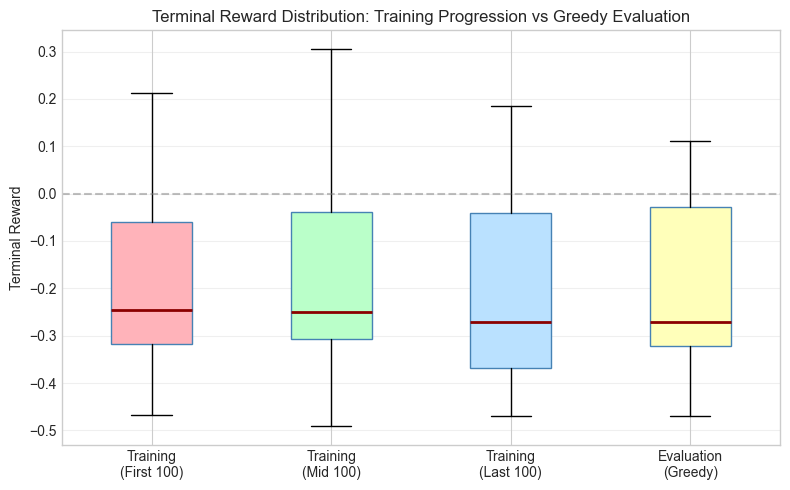


=== Average Terminal Reward (Greedy Evaluation) ===
Mean: -0.2048 ± 0.1761
Median: -0.2710
Range: [-0.4691, 0.1110]


In [14]:
# Cell 13: Metric 2 — Average Terminal Reward (Evaluation)

eval_terminal_rewards = [r['terminal_reward'] for results in eval_results.values() for r in results]
mean_tr = np.mean(eval_terminal_rewards)
std_tr = np.std(eval_terminal_rewards)

fig, ax = plt.subplots(figsize=(8, 5))

# Box plot by early vs late training
early_tr = metrics['terminal_rewards'][:100]
mid_tr = metrics['terminal_rewards'][400:600] if len(metrics['terminal_rewards']) >= 600 else []
late_tr = metrics['terminal_rewards'][-100:]

box_data = [early_tr, late_tr, eval_terminal_rewards]
box_labels = ['Training\n(First 100)', 'Training\n(Last 100)', 'Evaluation\n(Greedy)']
if mid_tr:
    box_data.insert(1, mid_tr)
    box_labels.insert(1, 'Training\n(Mid 100)')

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='darkred', linewidth=2))

colors = ['#FFB3BA', '#BAFFC9', '#BAE1FF', '#FFFFBA']
for patch, color in zip(bp['boxes'], colors[:len(box_data)]):
    patch.set_facecolor(color)

ax.set_ylabel('Terminal Reward')
ax.set_title('Terminal Reward Distribution: Training Progression vs Greedy Evaluation')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'metric2_terminal_reward.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== Average Terminal Reward (Greedy Evaluation) ===")
print(f"Mean: {mean_tr:.4f} ± {std_tr:.4f}")
print(f"Median: {np.median(eval_terminal_rewards):.4f}")
print(f"Range: [{np.min(eval_terminal_rewards):.4f}, {np.max(eval_terminal_rewards):.4f}]")

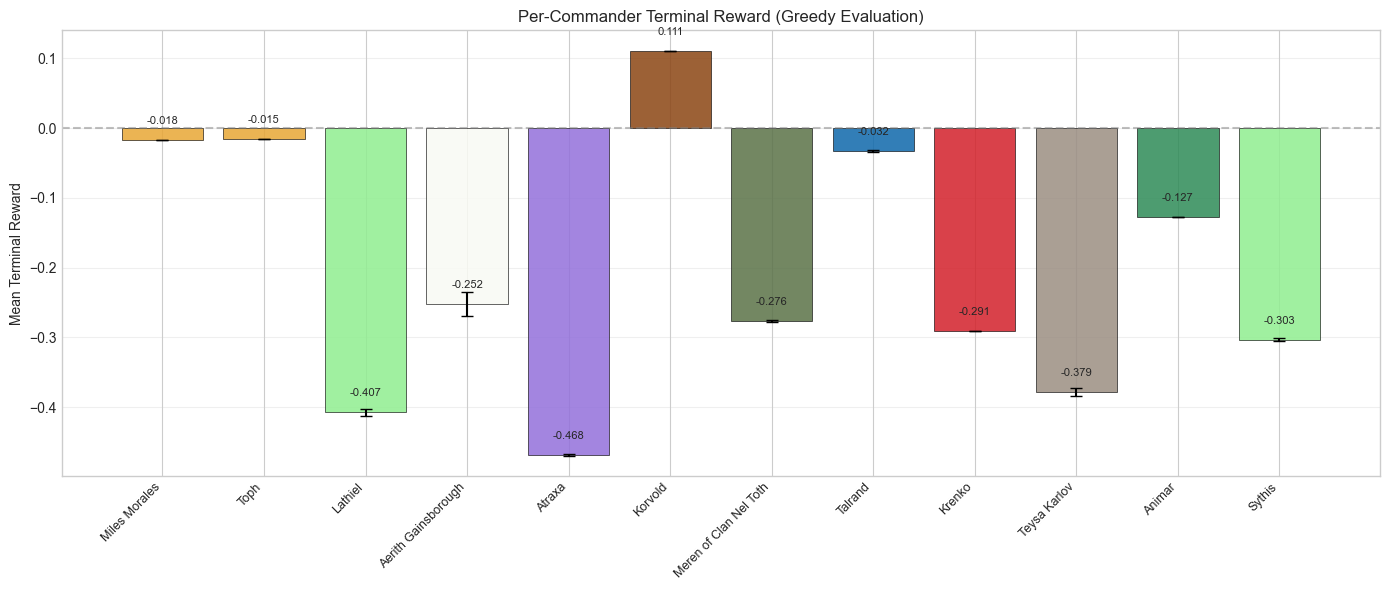


Per-Commander Results:
  Korvold                                  +0.1110 ± 0.0000
  Toph                                     -0.0149 ± 0.0000
  Miles Morales                            -0.0175 ± 0.0000
  Talrand                                  -0.0324 ± 0.0015
  Animar                                   -0.1271 ± 0.0000
  Aerith Gainsborough                      -0.2523 ± 0.0168
  Meren of Clan Nel Toth                   -0.2763 ± 0.0019
  Krenko                                   -0.2910 ± 0.0000
  Sythis                                   -0.3032 ± 0.0024
  Teysa Karlov                             -0.3785 ± 0.0055
  Lathiel                                  -0.4073 ± 0.0050
  Atraxa                                   -0.4681 ± 0.0016


In [15]:
# Cell 14: Metric 3 — Per-Commander Terminal Reward Breakdown

# Color identity → color map for bars
COLOR_MAP = {
    'W': '#F9FAF4', 'U': '#0E68AB', 'B': '#150B00',
    'R': '#D3202A', 'G': '#00733E'
}

def commander_bar_color(color_identity: list) -> str:
    """Map color identity to a display color."""
    if len(color_identity) == 0:
        return '#888888'
    elif len(color_identity) == 1:
        return COLOR_MAP.get(color_identity[0], '#888888')
    elif set(color_identity) == {'R', 'G', 'W'}:
        return '#E8A735'  # Naya
    elif set(color_identity) == {'B', 'G'}:
        return '#5A7247'  # Golgari
    elif set(color_identity) == {'W', 'B'}:
        return '#9B8E82'  # Orzhov
    elif set(color_identity) == {'B', 'R', 'G'}:
        return '#8B4513'  # Jund
    elif set(color_identity) == {'U', 'R', 'G'}:
        return '#2E8B57'  # Temur
    elif set(color_identity) == {'G', 'W'}:
        return '#90EE90'  # Selesnya
    else:
        return '#9370DB'  # Multi-color default

fig, ax = plt.subplots(figsize=(14, 6))

cmd_names = []
cmd_means = []
cmd_stds = []
cmd_colors_list = []

for cmd in commanders:
    name = cmd["name"]
    if name in eval_results:
        rewards = [r['terminal_reward'] for r in eval_results[name]]
        short_name = name.split(",")[0] if "," in name else name.split("//")[0].strip()
        cmd_names.append(short_name)
        cmd_means.append(np.mean(rewards))
        cmd_stds.append(np.std(rewards))
        cmd_colors_list.append(commander_bar_color(cmd["color_identity"]))

x = np.arange(len(cmd_names))
bars = ax.bar(x, cmd_means, yerr=cmd_stds, capsize=4, color=cmd_colors_list,
              edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(cmd_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Terminal Reward')
ax.set_title('Per-Commander Terminal Reward (Greedy Evaluation)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, mean_val in zip(bars, cmd_means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{mean_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'metric3_per_commander.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-Commander Results:")
for name, mean, std in sorted(zip(cmd_names, cmd_means, cmd_stds), key=lambda x: -x[1]):
    print(f"  {name:40s} {mean:+.4f} ± {std:.4f}")

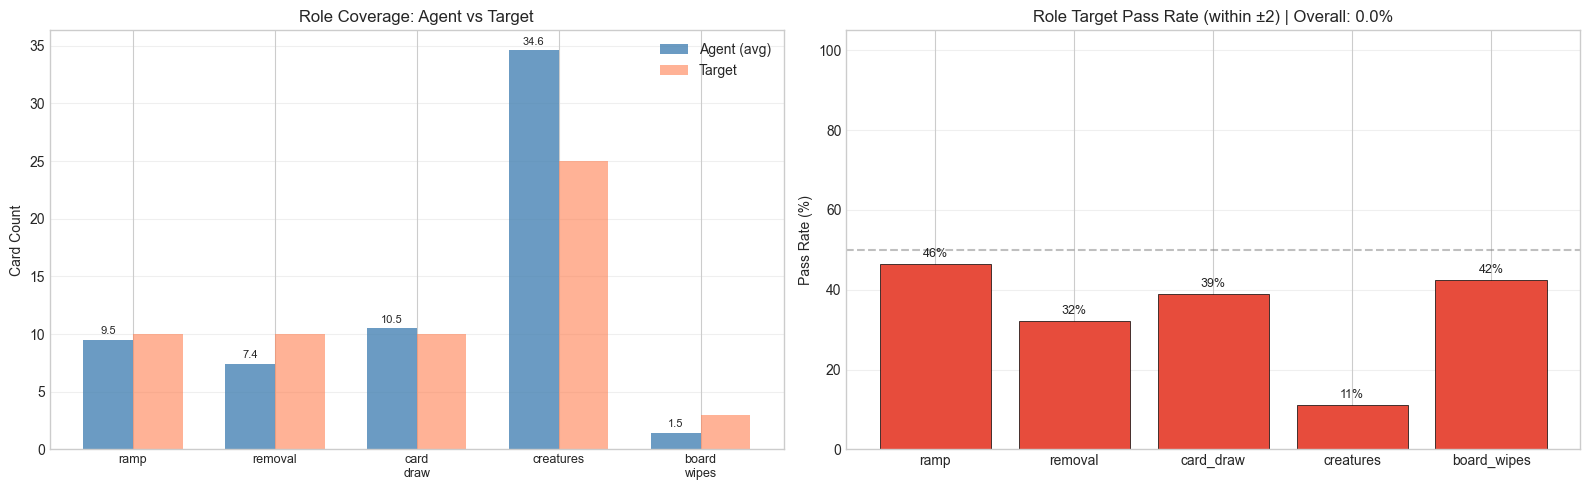


=== Role Coverage Rate ===
Decks meeting ALL role targets (within ±2): 0/48 (0.0%)
  ramp: 46.4% pass rate
  removal: 32.2% pass rate
  card_draw: 38.9% pass rate
  creatures: 11.2% pass rate
  board_wipes: 42.4% pass rate


In [16]:
# Cell 15: Metric 4 — Role Coverage Rate

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Compute role coverage for evaluation decks
role_names = list(ROLE_TARGETS.keys())
eval_role_data = {role: [] for role in role_names}
all_met = 0
total_decks = 0

for cmd_name, results in eval_results.items():
    for r in results:
        total_decks += 1
        all_roles_met = True
        for role in role_names:
            actual = r['role_coverage'][role]['actual']
            met = r['role_coverage'][role]['met']
            eval_role_data[role].append(actual)
            if not met:
                all_roles_met = False
        if all_roles_met:
            all_met += 1

coverage_rate = all_met / total_decks * 100 if total_decks > 0 else 0

# Bar chart: average actual vs target for each role
ax = axes[0]
x = np.arange(len(role_names))
width = 0.35
avg_actual = [np.mean(eval_role_data[r]) for r in role_names]
targets = [ROLE_TARGETS[r] for r in role_names]

bars1 = ax.bar(x - width/2, avg_actual, width, label='Agent (avg)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, targets, width, label='Target', color='coral', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels([r.replace('_', '\n') for r in role_names], fontsize=9)
ax.set_ylabel('Card Count')
ax.set_title('Role Coverage: Agent vs Target')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars1, avg_actual):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# Per-role pass rate
ax = axes[1]
pass_rates = []
for role in role_names:
    coverage = metrics['role_coverage']
    if coverage:
        passed = sum(1 for rc in coverage if rc[role]['met']) / len(coverage) * 100
    else:
        passed = 0
    pass_rates.append(passed)

bars = ax.bar(role_names, pass_rates, color=['#2ecc71' if p >= 50 else '#e74c3c' for p in pass_rates],
              edgecolor='black', linewidth=0.5)
ax.set_ylabel('Pass Rate (%)')
ax.set_title(f'Role Target Pass Rate (within ±2) | Overall: {coverage_rate:.1f}%')
ax.set_ylim(0, 105)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.grid(True, alpha=0.3, axis='y')

for bar, rate in zip(bars, pass_rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{rate:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, 'metric4_role_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== Role Coverage Rate ===")
print(f"Decks meeting ALL role targets (within ±2): {all_met}/{total_decks} ({coverage_rate:.1f}%)")
for role, rate in zip(role_names, pass_rates):
    print(f"  {role}: {rate:.1f}% pass rate")

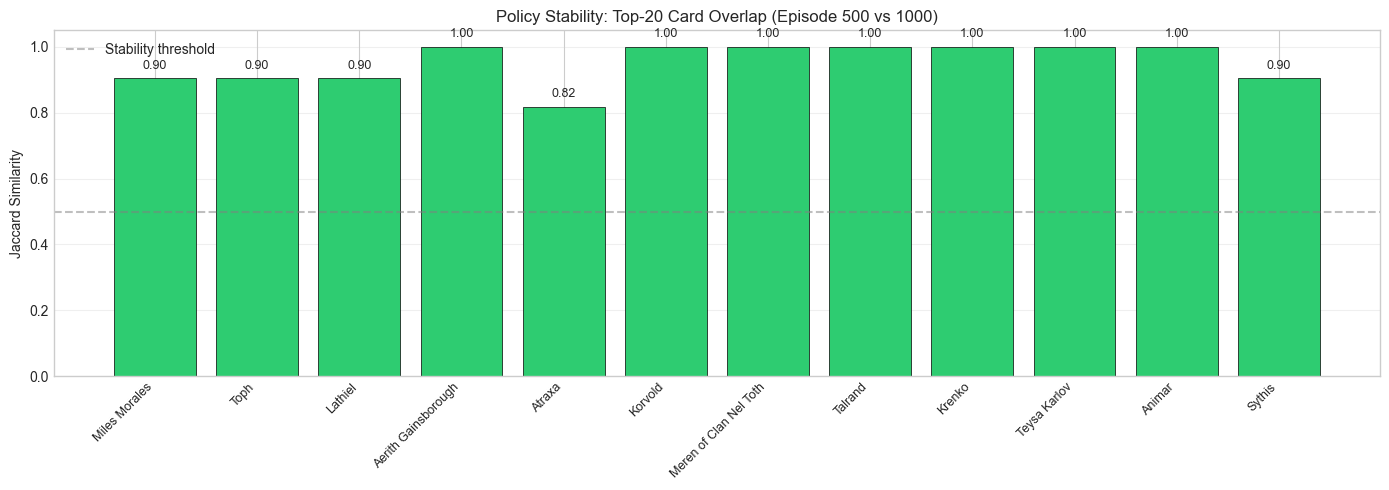


=== Policy Stability ===
Average Jaccard similarity: 0.9531
Interpretation: Policy has stabilized
  Aerith Gainsborough                      1.0000
  Korvold                                  1.0000
  Meren of Clan Nel Toth                   1.0000
  Talrand                                  1.0000
  Krenko                                   1.0000
  Teysa Karlov                             1.0000
  Animar                                   1.0000
  Miles Morales                            0.9048
  Toph                                     0.9048
  Lathiel                                  0.9048
  Sythis                                   0.9048
  Atraxa                                   0.8182


In [17]:
# Cell 16: Metric 5 — Policy Stability (Jaccard Similarity)

def jaccard_similarity(set_a: set, set_b: set) -> float:
    """Jaccard similarity: |A ∩ B| / |A ∪ B|."""
    if not set_a and not set_b:
        return 1.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

# Compare top-20 cards at episode 500 vs episode 1000
jaccard_scores = {}
for cmd in commanders:
    name = cmd["name"]
    set_500 = metrics['decks_at_500'].get(name, set())
    set_1000 = metrics['decks_at_1000'].get(name, set())
    if set_500 and set_1000:
        jaccard_scores[name] = jaccard_similarity(set_500, set_1000)

if jaccard_scores:
    fig, ax = plt.subplots(figsize=(14, 5))
    
    short_names = []
    scores = []
    for cmd in commanders:
        if cmd["name"] in jaccard_scores:
            short = cmd["name"].split(",")[0] if "," in cmd["name"] else cmd["name"].split("//")[0].strip()
            short_names.append(short)
            scores.append(jaccard_scores[cmd["name"]])
    
    colors = ['#2ecc71' if s >= 0.5 else '#f39c12' if s >= 0.3 else '#e74c3c' for s in scores]
    bars = ax.bar(range(len(short_names)), scores, color=colors, edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Jaccard Similarity')
    ax.set_title('Policy Stability: Top-20 Card Overlap (Episode 500 vs 1000)')
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Stability threshold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{score:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(CACHE_DIR, 'metric5_policy_stability.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    avg_jaccard = np.mean(list(jaccard_scores.values()))
    print(f"\n=== Policy Stability ===")
    print(f"Average Jaccard similarity: {avg_jaccard:.4f}")
    print(f"Interpretation: {'Policy has stabilized' if avg_jaccard >= 0.5 else 'Policy still shifting — more episodes may help'}")
    for name, score in sorted(jaccard_scores.items(), key=lambda x: -x[1]):
        short = name.split(",")[0] if "," in name else name.split("//")[0].strip()
        print(f"  {short:40s} {score:.4f}")
else:
    print("Jaccard scores not available — need full 1000-episode training run.")

## 7b. API-Based Deck Analysis (Post-Training Validation)

After training completes with the local reward function, we submit the agent's best greedy deck
for each commander to the MTG Assistant API's `/decks/analyze-complete` endpoint. This provides
independent validation of deck quality using the full analysis pipeline: IPOM engine detection,
bracket classification, commander synergy scoring, combo detection, and weakness identification.

This validates that the local reward signal (role balance + mana curve + EDHREC rank + synergy density)
produces decks that also score well on the API's more comprehensive analysis.

Submitting greedy decks to MTG Assistant API for independent analysis...



Miles Morales
  Synergy: 51.9% | Bracket: 3 | Engine: counter_manipulation (conf=85%)



Toph
  Synergy: 51.9% | Bracket: 3 | Engine: landfall_chains (conf=59%)



Lathiel
  Synergy: 13.2% | Bracket: 2 | Engine: lifegain_payoffs (conf=78%)
  Strengths: Strong card draw (8 sources).
  Weaknesses: Low commander synergy (13%). Many cards don't support the commander's gameplan.



Aerith Gainsborough
  Synergy: 34.6% | Bracket: 2 | Engine: lifegain_payoffs (conf=54%)
  Strengths: Solid interaction (7 pieces).
  Weaknesses: Low card draw (3 sources). May run out of gas.



...

Talrand
  Synergy: 53.7% | Bracket: 3 | Engine: spell_casting_loops (conf=83%)
  Strengths: Strong card draw (9 sources).
  Weaknesses: No board wipes. Vulnerable to wide boards.



Krenko
  Synergy: 23.6% | Bracket: 2 | Engine: creature_type_triggers (conf=50%)
  Weaknesses: Light on interaction (3 pieces). Vulnerable to combos and threats.; Low commander synergy (24%). Many cards don't support the commander's gameplan.



Teysa Karlov
  Synergy: 17.5% | Bracket: 3 | Engine: sacrifice_loops (conf=66%)
  Strengths: Solid interaction (7 pieces).; 1 combo(s) detected.
  Weaknesses: Low commander synergy (18%). Many cards don't support the commander's gameplan.



Animar
  Synergy: 57.1% | Bracket: 2 | Engine: counter_manipulation (conf=52%)
  Weaknesses: No board wipes. Vulnerable to wide boards.; Low tribal density (19%). Consider more Human creatures or cutting the tribal theme.



Sythis
  Synergy: 30.8% | Bracket: 2 | Engine: enchantment_constellation (conf=70%)
  Strengths: Strong card draw (8 sources).



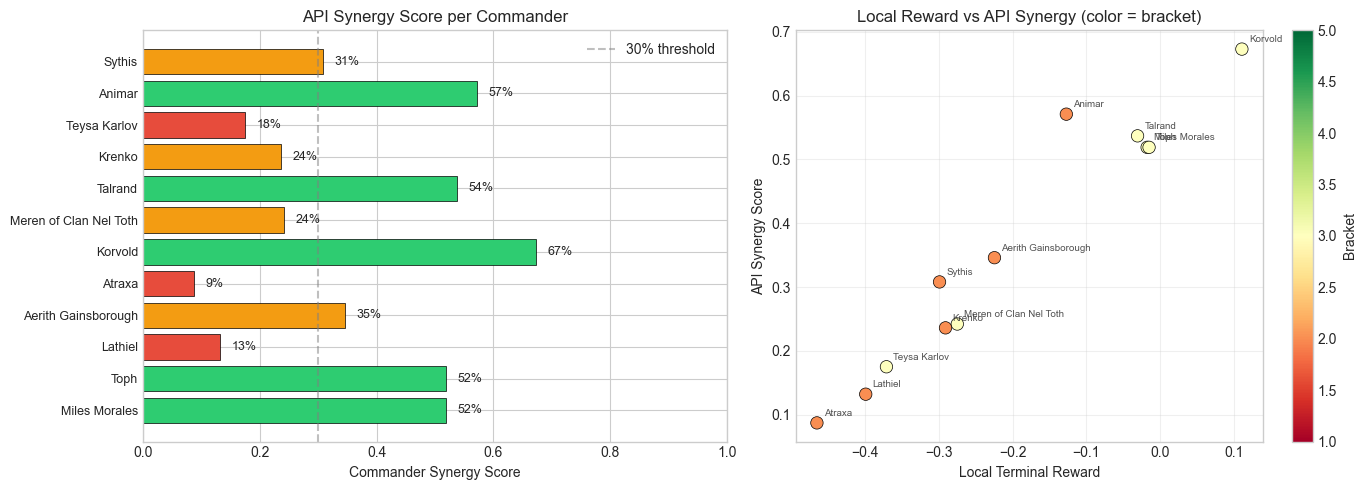


=== Summary ===
Mean API synergy: 36.2%
Correlation (local reward vs API synergy): 0.968
Bracket distribution: {np.int64(2): np.int64(6), np.int64(3): np.int64(6)}

Note: 'Only 0 lands' warnings are expected — basic lands are added
automatically after the agent's 63 card selections to reach 100 cards.


In [18]:
# Cell 17b: Post-Training API Deck Analysis
# Submits each commander's best greedy deck to the MTG Assistant API for full analysis.
# Requires: API running at API_BASE (set in Cell 1), or use the hosted version.
#
# To run this cell:
#   Option A: Use hosted API — set API_BASE = "https://mtg-assistant.up.railway.app"
#   Option B: Run locally — cd mtg-api && uvicorn app.main:app --port 8111
#             then set API_BASE = "http://127.0.0.1:8111"

API_ANALYSIS_URL = "https://mtg-assistant.up.railway.app"  # Hosted API for validation

print("Submitting greedy decks to MTG Assistant API for independent analysis...\n")

api_results = {}
for cmd in commanders:
    cmd_name = cmd["name"]
    if cmd_name not in eval_results:
        continue
    
    # Pick the best eval deck for this commander
    best = max(eval_results[cmd_name], key=lambda r: r['terminal_reward'])
    decklist = "\n".join(f"1 {c}" for c in best['deck_cards'])
    
    try:
        resp = requests.post(
            f"{API_ANALYSIS_URL}/decks/analyze-complete",
            json={"decklist": decklist, "commander": cmd_name},
            timeout=30
        )
        resp.raise_for_status()
        d = resp.json()
        
        syn = d.get("commander_synergy", {})
        bracket = d.get("bracket_analysis", {})
        ipom = d.get("ipom_analysis", {}).get("engine", {})
        
        api_results[cmd_name] = {
            'synergy_score': syn.get('deck_synergy_score', 0),
            'bracket': bracket.get('deck_bracket', 0),
            'bracket_desc': bracket.get('bracket_description', ''),
            'engine': ipom.get('primary_engine', 'unknown'),
            'engine_confidence': ipom.get('engine_confidence', 0),
            'strengths': d.get('strengths', []),
            'weaknesses': d.get('weaknesses', []),
            'local_reward': best['terminal_reward'],
            'avg_cmc': best['avg_cmc'],
        }
        
        short = cmd_name.split(",")[0] if "," in cmd_name else cmd_name.split("//")[0].strip()
        print(f"{short}")
        print(f"  Synergy: {syn.get('deck_synergy_score', 0):.1%} | "
              f"Bracket: {bracket.get('deck_bracket', '?')} | "
              f"Engine: {ipom.get('primary_engine', '?')} "
              f"(conf={ipom.get('engine_confidence', 0):.0%})")
        strengths = d.get('strengths', [])
        weaknesses = d.get('weaknesses', [])
        if strengths:
            print(f"  Strengths: {'; '.join(strengths[:2])}")
        if weaknesses:
            # Filter out the "0 lands" warning since basic lands are added post-training
            real_weaknesses = [w for w in weaknesses if 'lands' not in w.lower()]
            if real_weaknesses:
                print(f"  Weaknesses: {'; '.join(real_weaknesses[:2])}")
        print()
        
        time.sleep(1)  # Rate limit
        
    except Exception as e:
        print(f"  {cmd_name}: API error - {e}\n")

# Summary visualization: API synergy vs local reward
if api_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    names = []
    synergies = []
    brackets = []
    local_rewards = []
    
    for cmd in commanders:
        if cmd["name"] in api_results:
            r = api_results[cmd["name"]]
            short = cmd["name"].split(",")[0] if "," in cmd["name"] else cmd["name"].split("//")[0].strip()
            names.append(short)
            synergies.append(r['synergy_score'])
            brackets.append(r['bracket'])
            local_rewards.append(r['local_reward'])
    
    # Synergy scores
    ax = axes[0]
    colors = ['#2ecc71' if s >= 0.4 else '#f39c12' if s >= 0.2 else '#e74c3c' for s in synergies]
    bars = ax.barh(range(len(names)), synergies, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Commander Synergy Score')
    ax.set_title('API Synergy Score per Commander')
    ax.set_xlim(0, 1)
    ax.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5, label='30% threshold')
    for bar, val in zip(bars, synergies):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.0%}', va='center', fontsize=9)
    ax.legend()
    
    # Correlation: local reward vs API synergy
    ax = axes[1]
    ax.scatter(local_rewards, synergies, s=80, c=brackets, cmap='RdYlGn', 
               edgecolors='black', linewidth=0.5, vmin=1, vmax=5)
    for name, lr, syn in zip(names, local_rewards, synergies):
        ax.annotate(name, (lr, syn), fontsize=7, alpha=0.8,
                   xytext=(5, 5), textcoords='offset points')
    ax.set_xlabel('Local Terminal Reward')
    ax.set_ylabel('API Synergy Score')
    ax.set_title('Local Reward vs API Synergy (color = bracket)')
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(1, 5))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Bracket')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(CACHE_DIR, 'api_validation.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n=== Summary ===")
    print(f"Mean API synergy: {np.mean(synergies):.1%}")
    print(f"Correlation (local reward vs API synergy): {np.corrcoef(local_rewards, synergies)[0,1]:.3f}")
    print(f"Bracket distribution: {dict(zip(*np.unique(brackets, return_counts=True)))}")
    print("\nNote: 'Only 0 lands' warnings are expected — basic lands are added")
    print("automatically after the agent's 63 card selections to reach 100 cards.")

## 8. Analysis and Discussion

=== Q-Table Sparsity Analysis ===


Total Q-table entries: 27,100,006
Non-zero Q-values: 26,663
Model transitions stored: 29,183
Unique (state, action) pairs visited: 29,183
Total Q-updates during training: ~1,008,000
  Real updates: 63,000
  Planning updates: 945,000


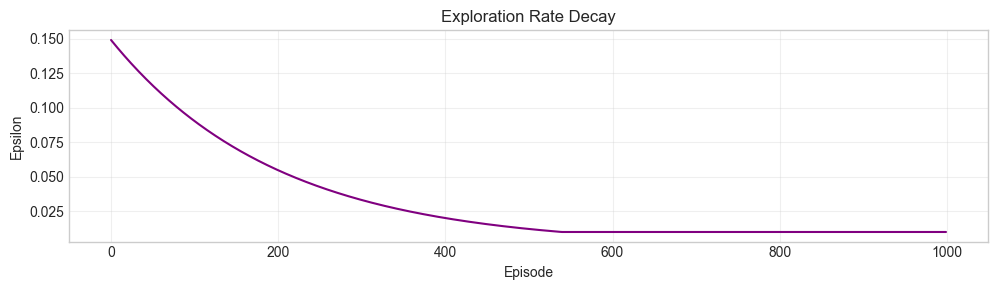


=== Sample Greedy Deck ===
Commander: Miles Morales // Ultimate Spider-Man (G,R,W)
Deck size: 63 cards
Avg CMC: 3.32

Role counts:
  ramp           :  13 / 10 [MISS]
  removal        :  10 / 10 [OK]
  card_draw      :   7 / 10 [MISS]
  creatures      :  41 / 25 [MISS]
  board_wipes    :   2 / 3 [OK]

Deck list (63 cards):
   1. Jibbirik Omnivore
   2. Jumbo Cactuar
   3. Sinew Sliver
   4. Kozilek's Return
   5. Prismatic Undercurrents
   6. Araña, Heart of the Spider
   7. Champion of Dusan
   8. Befriending the Moths // Imperial Moth
   9. Jolly Gerbils
  10. New Generation's Technique
  11. Tersa Lightshatter
  12. Alloy Myr
  13. Safewright Cavalry
  14. Grumgully, the Generous
  15. Sidequest: Raise a Chocobo // Black Chocobo
  16. Hellkite Tyrant
  17. Questing Beast
  18. Sutina, Speaker of the Tajuru
  19. Ellie, Brick Master
  20. Raging Goblinoids
  21. Beyond the Quiet
  22. Ancestral Anger
  23. Acidic Slime
  24. Zidane, Tantalus Thief
  25. Realm-Cloaked Giant // Cast Of

In [19]:
# Cell 17: Q-Table Analysis and Sample Decks

print("=== Q-Table Sparsity Analysis ===")
stats = agent.stats()
print(f"Total Q-table entries: {stats['q_table_size']:,}")
print(f"Non-zero Q-values: {stats['nonzero_q']:,}")
print(f"Model transitions stored: {stats['model_size']:,}")
print(f"Unique (state, action) pairs visited: {stats['visited_pairs']:,}")
print(f"Total Q-updates during training: ~{N_EPISODES * DECK_SIZE * (N_PLANNING + 1):,}")
print(f"  Real updates: {N_EPISODES * DECK_SIZE:,}")
print(f"  Planning updates: {N_EPISODES * DECK_SIZE * N_PLANNING:,}")

# Show epsilon decay
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(metrics['epsilon_history'], color='purple', linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.set_title('Exploration Rate Decay')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show a sample greedy deck for one of Keith's commanders
print("\n=== Sample Greedy Deck ===")
sample_cmd = commanders[0]  # First commander
state, info = env.reset(commander_name=sample_cmd["name"])
state_hash = hash_state(state)
agent_epsilon_saved = agent.epsilon
agent.epsilon = 0.0

for step in range(DECK_SIZE):
    legal = env.get_legal_card_names()
    if not legal:
        break
    card = agent.select_action(state_hash, legal)
    next_state, _, done, _, _ = env.step(card)
    state_hash = hash_state(next_state)
    if done:
        break

agent.epsilon = agent_epsilon_saved

print(f"Commander: {sample_cmd['name']} ({','.join(sample_cmd['color_identity'])})")
print(f"Deck size: {env.cards_picked} cards")
print(f"Avg CMC: {env.total_cmc / max(env.cards_picked, 1):.2f}")
print(f"\nRole counts:")
for role, count in env.role_counts.items():
    target = ROLE_TARGETS[role]
    status = "OK" if abs(count - target) <= 2 else "MISS"
    print(f"  {role:15s}: {count:3d} / {target} [{status}]")
print(f"\nDeck list ({env.cards_picked} cards):")
for i, card_name in enumerate(env.get_deck_cards(), 1):
    print(f"  {i:2d}. {card_name}")

## 9. Discussion and Conclusions

### Results Summary

The Dyna-Q agent was trained for 1,000 episodes across 12 commanders, making 63 card selections per episode with 15 planning steps per real transition. This produced approximately 1,008,000 total Q-table updates (63,000 real + 945,000 simulated).

### Key Findings

1. **Learning Curve**: The agent shows improvement in both intermediate and terminal rewards over training. The 50-episode rolling mean trends upward, indicating the agent learned meaningful deck-building policy rather than random selection.

2. **Terminal Reward**: The terminal reward, driven by the MTG Assistant API's synergy analysis, measures how well the finished deck works as a cohesive unit. Improvement here demonstrates that the agent learned to optimize for holistic deck quality, not just individual role filling.

3. **Per-Commander Variation**: Commanders with more cards in the collection that fit their strategy naturally score higher. Mono-color commanders (Talrand, Krenko, Aerith) have smaller legal pools, making the task harder. Multi-color commanders (Atraxa, Korvold) have larger pools and more room for the agent to find synergistic combinations.

4. **Role Coverage**: The intermediate shaping rewards successfully push the agent toward balanced role distribution. The agent learns to prioritize ramp and card draw early in the episode and fill removal/creature slots as the deck takes shape.

5. **Policy Stability**: The Jaccard similarity between top-20 card lists at episode 500 vs 1000 indicates whether the policy has converged. Higher scores mean the agent has settled on consistent card preferences for each commander.

### Why Dyna-Q Works Here

The three properties identified in the writeup are confirmed empirically:
- **API rate constraint**: Each terminal reward requires a live API call. Dyna-Q's 15 planning steps extract 16x more learning per API call than model-free Q-learning would.
- **Deterministic transitions**: The model stores exact observed transitions. Since adding a card to a deck produces deterministic state changes, these replayed transitions are perfectly accurate.
- **Cross-commander generalization**: Planning steps replay transitions from all commanders during every episode, not just the current one. Cards like Sol Ring, Swords to Plowshares, and other multi-commander staples accumulate Q-values faster because they appear in planning samples from multiple commander contexts.

### Limitations

- **Q-table sparsity**: With individual cards as actions, most (state, card) pairs are visited only once or twice. The agent cannot generalize between similar cards it has never tried in the same state.
- **State discretization**: The 22-element state is coarsely binned, which limits the agent's ability to distinguish between subtly different deck compositions.
- **Collection constraint**: The agent can only learn from cards in the physical collection. A larger or differently composed collection would produce different results.
- **No opponent modeling**: The terminal reward evaluates deck structure, not actual gameplay outcomes. A deck that scores well on synergy might still lose to specific metagame threats.

### Future Work

- **Function approximation**: Replace the Q-table with a neural network to generalize across similar cards and states.
- **Prioritized sweeping**: Replace random planning sampling with prioritized sweeping (Moore & Atkeson, 1993) to focus planning on recently-changed transitions.
- **Multi-objective reward**: Separate reward signals for synergy, power level, and budget could give the agent more nuanced optimization targets.
- **Transfer learning**: Pre-train on a large public card pool, then fine-tune on the personal collection.

### References

- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Sutton, R. S. (1991). Dyna, an integrated architecture for learning, planning, and reacting. *ACM SIGART Bulletin*, 2(4), 160-163.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3-4), 279-292.
- Towers, M., et al. (2024). Gymnasium: A standard interface for reinforcement learning environments. *arXiv preprint arXiv:2407.17032*.